Dataset: https://github.com/deepchem/deepchem/blob/master/datasets/membrane_permeability.sdf


This project focuses on predicting the membrane permeability of drug-like molecules using Graph Neural Networks (GNNs) in PyTorch. Membrane permeability, expressed as LogP (RRCK), indicates how easily a molecule can pass through a cell membrane—an essential factor in drug absorption and effectiveness.

The dataset, stored in SDF format, contains molecules with atomic and bonding information along with measured LogP values. Each molecule is converted into a graph where atoms are nodes and bonds are edges. Using RDKit and PyTorch Geometric, the data is processed into a format suitable for training a GNN model.

A Graph Neural Network is trained to learn structural patterns that correlate with membrane permeability. The goal is to build a regression model that predicts LogP values based solely on molecular structure, enabling faster and more cost-effective drug screening.

In [1]:
# Install RDKit and PyTorch Geometric
!pip install rdkit-pypi

# Install PyTorch Geometric (CPU version for now)
!pip install torch torchvision torchaudio
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install torch-geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 141.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 108.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 112.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [21]:
import os
import torch
import numpy as np
from rdkit import Chem
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [23]:
def enhanced_atom_features(atom):
    return [
        atom.GetAtomicNum(),            # atomic number
        atom.GetDegree(),               # number of bonds
        atom.GetTotalNumHs(),           # hydrogen count
        atom.GetImplicitValence(),      # valence electrons
        int(atom.GetIsAromatic()),      # 1 if aromatic
        int(atom.GetHybridization())    # encoded hybridization
    ]

from torch_geometric.data import Data

data_list = []

for mol, logp in zip(mols_valid, logp_scaled):
    # Node features
    x = torch.tensor([enhanced_atom_features(atom) for atom in mol.GetAtoms()],
                     dtype=torch.float)

    # Edges (bond pairs)
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])  # undirected graph

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    # Target
    y = torch.tensor([logp], dtype=torch.float)

    # Create Data object
    graph = Data(x=x, edge_index=edge_index, y=y)
    data_list.append(graph)

print("Graphs created:", len(data_list))

Graphs created: 201


In [24]:
# Shuffle and split the data
total_size = len(data_list)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_data, val_data, test_data = random_split(
    data_list,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Dataset split:")
print("Training graphs:", len(train_data))
print("Validation graphs:", len(val_data))
print("Test graphs:", len(test_data))

Dataset split:
Training graphs: 160
Validation graphs: 20
Test graphs: 21


In [25]:
from torch_geometric.loader import DataLoader

# Set your batch size
batch_size = 32

# Create loaders for training, validation, and testing
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

In [63]:
class UltraDeepGCNModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.convs = nn.ModuleList([GCNConv(input_dim if i == 0 else 16, 16) for i in range(10)])
        self.lin = nn.Linear(16, 1)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)

class DeepMediumGCNModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.convs = nn.ModuleList([GCNConv(input_dim if i == 0 else 32, 32) for i in range(6)])
        self.lin = nn.Linear(32, 1)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)

class WideShallowGCNModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv1 = GCNConv(input_dim, 128)
        self.conv2 = GCNConv(128, 128)
        self.lin = nn.Linear(128, 1)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)

class VeryWideShallowGCN(nn.Module):
    def __init__(self, input_dim, hidden_dim=1024):
        super(VeryWideShallowGCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.lin1 = nn.Linear(hidden_dim, 512)
        self.lin2 = nn.Linear(512, 1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = F.relu(self.lin1(x))
        x = self.lin2(x)
        return x

In [69]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch.nn.functional as F

def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_model_state = None
    best_val_r2 = float('-inf')

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            output = model(batch.x, batch.edge_index, batch.batch)
            loss = loss_fn(output.view(-1), batch.y.view(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if verbose and epoch % 10 == 0:
            print(f"Epoch {epoch:02d} | Train Loss: {total_loss / len(train_loader):.4f}")

    return model


def evaluate_model(model, loader, verbose=True):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch.x, batch.edge_index, batch.batch)
            y_true += batch.y.view(-1).cpu().tolist()
            y_pred += pred.view(-1).cpu().tolist()

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    if verbose:
        print("Evaluation Results:")
        print(f"  MSE: {mse:.4f}")
        print(f"  MAE: {mae:.4f}")
        print(f"  R² Score: {r2:.4f}")

    return {"mse": mse, "mae": mae, "r2": r2}

model = UltraDeepGCNModel(input_dim=6).to(device)
train_model(model, train_loader, val_loader, epochs=50)
evaluate_model(model, test_loader)

model1 = DeepMediumGCNModel(input_dim=6).to(device)
train_model(model1, train_loader, val_loader, epochs=50)
evaluate_model(model1, test_loader)

model2 = WideShallowGCNModel(input_dim=6).to(device)
train_model(model2, train_loader, val_loader, epochs=50)
evaluate_model(model2, test_loader)

model3 = VeryWideShallowGCN(input_dim=6).to(device)
train_model(model3, train_loader, val_loader, epochs=50)
evaluate_model(model3, test_loader)

Epoch 10 | Train Loss: 1.0557
Epoch 20 | Train Loss: 1.0544
Epoch 30 | Train Loss: 1.0535
Epoch 40 | Train Loss: 1.0458
Epoch 50 | Train Loss: 0.9824
Evaluation Results:
  MSE: 0.6540
  MAE: 0.6907
  R² Score: 0.0124
Epoch 10 | Train Loss: 1.0036
Epoch 20 | Train Loss: 0.9225
Epoch 30 | Train Loss: 0.9040
Epoch 40 | Train Loss: 0.8836
Epoch 50 | Train Loss: 0.8939
Evaluation Results:
  MSE: 0.7314
  MAE: 0.6756
  R² Score: -0.1044
Epoch 10 | Train Loss: 0.9984
Epoch 20 | Train Loss: 0.9312
Epoch 30 | Train Loss: 0.9131
Epoch 40 | Train Loss: 0.9081
Epoch 50 | Train Loss: 0.8992
Evaluation Results:
  MSE: 0.7088
  MAE: 0.6737
  R² Score: -0.0703
Epoch 10 | Train Loss: 0.9869
Epoch 20 | Train Loss: 0.8975
Epoch 30 | Train Loss: 0.9144
Epoch 40 | Train Loss: 0.8758
Epoch 50 | Train Loss: 0.8681
Evaluation Results:
  MSE: 0.7579
  MAE: 0.6905
  R² Score: -0.1445


{'mse': 0.7578960524163699,
 'mae': 0.6904593094673362,
 'r2': -0.1445037002701628}

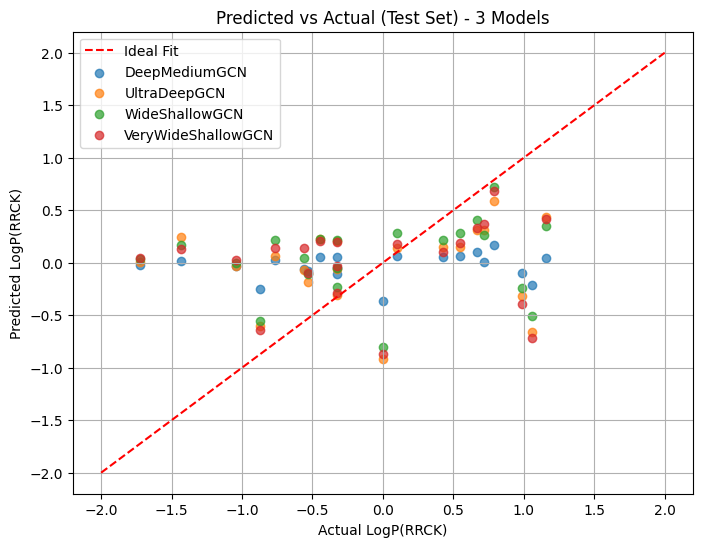

In [70]:
import matplotlib.pyplot as plt

# Helper function to get predictions from a model
def get_preds(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            y_true += batch.y.view(-1).cpu().tolist()
            y_pred += out.view(-1).cpu().tolist()
    return y_true, y_pred

# Get predictions from each model
y_true_1, y_pred_1 = get_preds(model, test_loader)
y_true_2, y_pred_2 = get_preds(model1, test_loader)
y_true_3, y_pred_3 = get_preds(model2, test_loader)
y_true_4, y_pred_4 = get_preds(model3, test_loader)


# Plot
plt.figure(figsize=(8, 6))
plt.plot([-2, 2], [-2, 2], 'r--', label='Ideal Fit')  # red diagonal line

plt.scatter(y_true_1, y_pred_1, label="DeepMediumGCN", alpha=0.7)
plt.scatter(y_true_2, y_pred_2, label="UltraDeepGCN", alpha=0.7)
plt.scatter(y_true_3, y_pred_3, label="WideShallowGCN", alpha=0.7)
plt.scatter(y_true_4, y_pred_4, label="VeryWideShallowGCN", alpha=0.7)

plt.xlabel("Actual LogP(RRCK)")
plt.ylabel("Predicted LogP(RRCK)")
plt.title("Predicted vs Actual (Test Set) - 3 Models")
plt.legend()
plt.grid(True)
plt.show()

The model performance did not turn out as well as expected primarily due to the limited size and variability of the dataset, which makes it difficult for graph neural networks to learn meaningful patterns. Additionally, the target variable (LogP(RRCK)) may have a weak or noisy correlation with the molecular graph structure alone, especially if important chemical or physical descriptors are missing from the input features. This can cause the models to default to predicting average values, resulting in low R² scores and poor alignment with actual values. Further improvements would likely require enhanced molecular features, more data, or a hybrid approach combining graph-based and traditional cheminformatics descriptors.